# IMDB Top Movies EDA (1980 – 2026)

Exploratory Data Analysis of 16,000+ top-rated IMDB movies spanning over four decades.

**Dataset:** `imdb_top_movies_1980_2026.csv`  
**Source:** IMDB (scraped/curated)  
**Key columns:** `title`, `year`, `runtime_minutes`, `genres`, `average_rating`, `num_votes`

---

### Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview & Quality](#2)
3. [Feature Engineering](#3)
4. [Distribution Analysis](#4)
5. [Temporal Trends](#5)
6. [Genre Analysis](#6)
7. [Rating Deep-Dive](#7)
8. [Popularity vs. Quality](#8)
9. [Decade Spotlights](#9)
10. [Key Findings](#10)

## 1. Setup & Data Loading <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Visual theme ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
ACCENT   = '#E50914'   # IMDB red
DARK     = '#1a1a2e'
PALETTE  = sns.color_palette('tab10')

plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('imdb_top_movies_1980_2026.csv')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(3)

Rows: 16,252  |  Columns: 9


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.00,Drama,9.30,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.00,"Action,Crime,Drama",9.10,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.00,"Action,Adventure,Sci-Fi",8.80,2811692,https://www.imdb.com/title/tt1375666


## 2. Data Overview & Quality <a id='2'></a>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16252 entries, 0 to 16251
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16252 non-null  str    
 1   title            16252 non-null  str    
 2   original_title   16252 non-null  str    
 3   year             16252 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16246 non-null  str    
 6   average_rating   16252 non-null  float64
 7   num_votes        16252 non-null  int64  
 8   imdb_url         16252 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 1.1 MB


In [5]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','50%'])

,count,mean,std,min,25%,50%,75%,max
year,16252.000000,2008.790118,11.581006,1980.000000,2001.000000,2011.000000,2018.000000,2026.000000
runtime_minutes,16251.000000,109.147376,22.110801,43.000000,94.000000,104.000000,119.000000,566.000000
average_rating,16252.000000,6.395194,1.050908,1.000000,5.800000,6.500000,7.100000,9.300000
num_votes,16252.000000,66331.718189,155736.555537,5000.000000,8397.500000,17266.000000,53867.250000,3182733.000000


In [6]:
# ── Missing values ────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %'    : (df.isna().sum() / len(df) * 100).round(2)
})
print('Missing values:\n')
print(missing[missing['Missing Count'] > 0])

print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Year range   : {df["year"].min()} – {df["year"].max()}')
print(f'Rating range : {df["average_rating"].min()} – {df["average_rating"].max()}')

Missing values:

                 Missing Count  Missing %
runtime_minutes              1       0.01
genres                       6       0.04

Duplicate rows: 0
Year range   : 1980 – 2026
Rating range : 1.0 – 9.3


> **Quality note:** The dataset is very clean — only 1 missing runtime and 6 missing genre values out of 16 k+ rows. No duplicates.

## 3. Feature Engineering <a id='3'></a>

In [7]:
# ── Decade & era ─────────────────────────────────────────────────────────
df['decade']      = (df['year'] // 10) * 10
df['decade_label'] = df['decade'].astype(str) + 's'

# ── Genre features ───────────────────────────────────────────────────────
df['genres_list']  = df['genres'].fillna('').str.split(',')
df['num_genres']   = df['genres_list'].apply(len)
df['primary_genre'] = df['genres_list'].apply(lambda g: g[0].strip() if g else 'Unknown')
df['is_multi_genre'] = (df['num_genres'] > 1).astype(int)

# ── Vote bins (popularity tier) ───────────────────────────────────────────
df['log_votes']   = np.log10(df['num_votes'])
df['pop_tier']    = pd.cut(
    df['num_votes'],
    bins   = [0, 10_000, 50_000, 200_000, 500_000, np.inf],
    labels = ['Niche', 'Known', 'Popular', 'Very Popular', 'Blockbuster']
)

# ── Runtime category ─────────────────────────────────────────────────────
df['runtime_cat'] = pd.cut(
    df['runtime_minutes'],
    bins   = [0, 90, 120, 150, np.inf],
    labels = ['< 90 min', '90–120 min', '120–150 min', '150+ min']
)

print('New columns added:', ['decade','decade_label','num_genres','primary_genre',
                              'is_multi_genre','log_votes','pop_tier','runtime_cat'])
df[['title','year','decade_label','primary_genre','num_genres','pop_tier','runtime_cat']].head(5)

New columns added: ['decade', 'decade_label', 'num_genres', 'primary_genre', 'is_multi_genre', 'log_votes', 'pop_tier', 'runtime_cat']


,title,year,decade_label,primary_genre,num_genres,pop_tier,runtime_cat
0,The Shawshank Redemption,1994,1990s,Drama,1,Blockbuster,120–150 min
1,The Dark Knight,2008,2000s,Action,3,Blockbuster,150+ min
2,Inception,2010,2010s,Action,3,Blockbuster,120–150 min
3,Fight Club,1999,1990s,Crime,3,Blockbuster,120–150 min
4,Interstellar,2014,2010s,Adventure,3,Blockbuster,150+ min


## 4. Distribution Analysis <a id='4'></a>

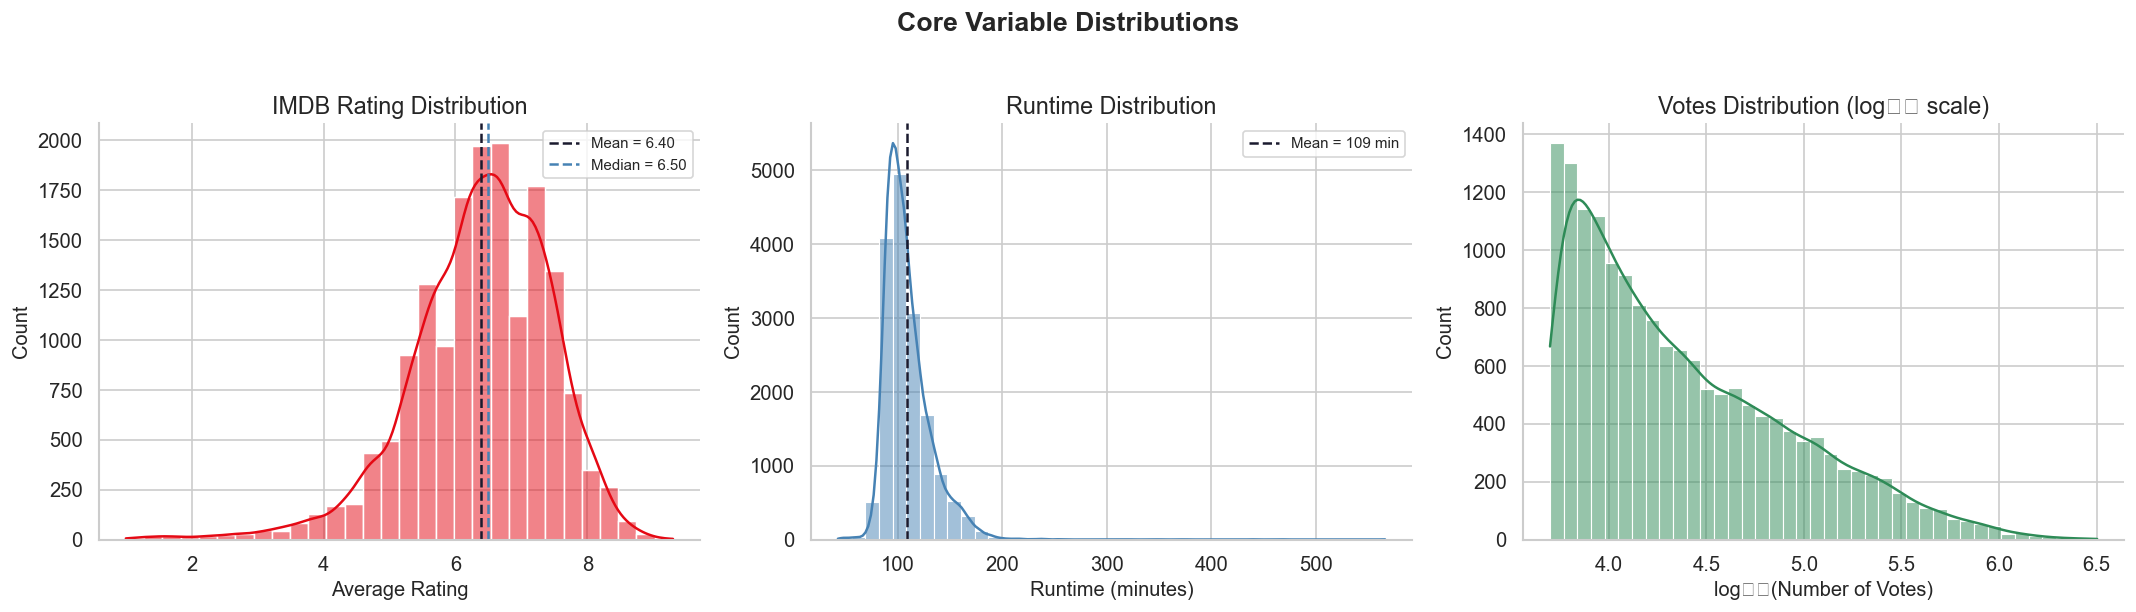

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Rating ────────────────────────────────────────────────────────────────
ax = axes[0]
sns.histplot(df['average_rating'], bins=30, kde=True, color=ACCENT, ax=ax)
ax.axvline(df['average_rating'].mean(), color=DARK, ls='--', lw=1.5, label=f'Mean = {df["average_rating"].mean():.2f}')
ax.axvline(df['average_rating'].median(), color='steelblue', ls='--', lw=1.5, label=f'Median = {df["average_rating"].median():.2f}')
ax.set_title('IMDB Rating Distribution')
ax.set_xlabel('Average Rating')
ax.legend(fontsize=9)

# ── Runtime ───────────────────────────────────────────────────────────────
ax = axes[1]
rt = df['runtime_minutes'].dropna()
sns.histplot(rt, bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(rt.mean(), color=DARK, ls='--', lw=1.5, label=f'Mean = {rt.mean():.0f} min')
ax.set_title('Runtime Distribution')
ax.set_xlabel('Runtime (minutes)')
ax.legend(fontsize=9)

# ── Votes (log scale) ─────────────────────────────────────────────────────
ax = axes[2]
sns.histplot(df['log_votes'], bins=40, kde=True, color='seagreen', ax=ax)
ax.set_title('Votes Distribution (log₁₀ scale)')
ax.set_xlabel('log₁₀(Number of Votes)')
# secondary x-axis in real votes
def log_to_votes(x):
    labels = [f'{10**v/1e3:.0f}K' if 10**v < 1e6 else f'{10**v/1e6:.1f}M' for v in x]
    return labels

plt.suptitle('Core Variable Distributions', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

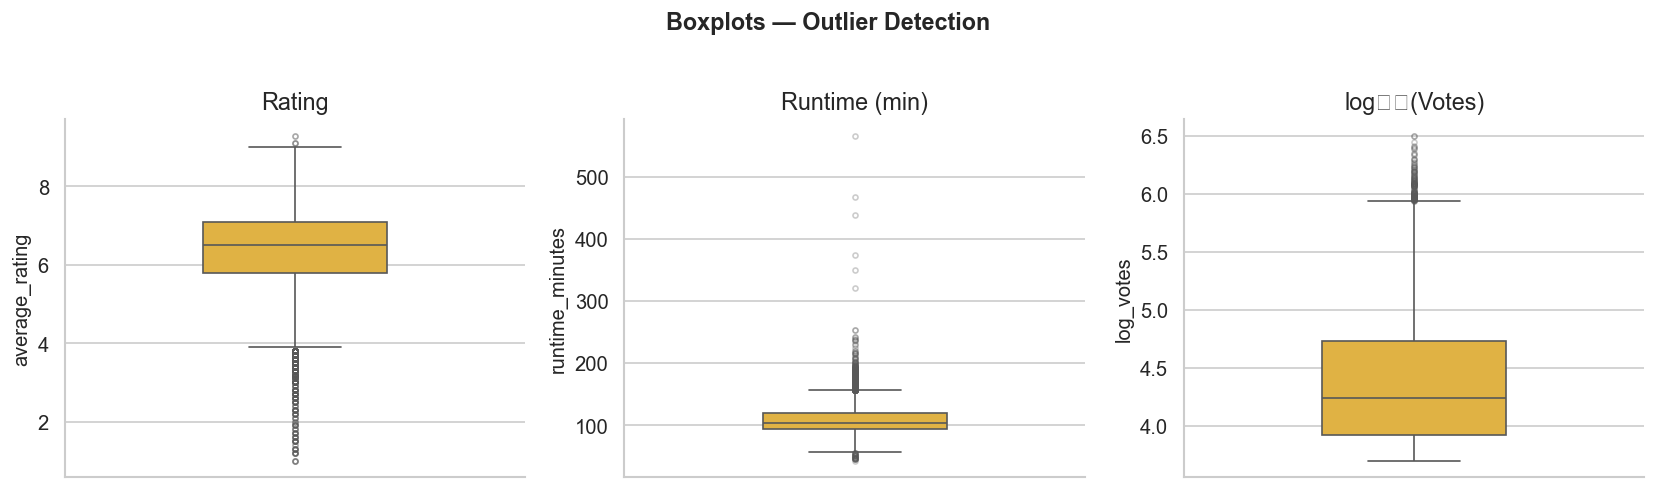

Longest films:


,title,year,runtime_minutes,average_rating
10171,Shoah,1985,566.00,8.70
6776,O.J.: Made in America,2016,467.00,8.90
9071,Satantango,1994,439.00,8.20
6124,The Best of Youth,2003,374.00,8.40
13557,Adolf Hitler: The Greatest Story Never Told,2013,350.00,7.20



Shortest films (< 60 min):


,title,year,runtime_minutes,average_rating
12920,Dragon Ball Z: Lord Slug,1991,43.00,6.50
6528,To the Forest of Firefly Lights,2011,45.00,7.80
11294,Dragon Ball Z: The Return of Cooler,1992,45.00,6.90
3761,The Garden of Words,2013,46.00,7.40
11727,Dragon Ball Z: Super Android 13!,1992,46.00,6.90


In [9]:
# ── Outlier overview with boxplots ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['average_rating', 'runtime_minutes', 'log_votes'],
    ['Rating', 'Runtime (min)', 'log₁₀(Votes)']
):
    sns.boxplot(y=df[col], color='#FABC2A', ax=ax, width=0.4,
                flierprops={'marker':'o','markersize':3,'alpha':0.3})
    ax.set_title(label)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Extreme runtimes ─────────────────────────────────────────────────────
print('Longest films:')
display(df.nlargest(5, 'runtime_minutes')[['title','year','runtime_minutes','average_rating']])

print('\nShortest films (< 60 min):')
display(df[df['runtime_minutes'] < 60].nsmallest(5,'runtime_minutes')[['title','year','runtime_minutes','average_rating']])

## 5. Temporal Trends <a id='5'></a>

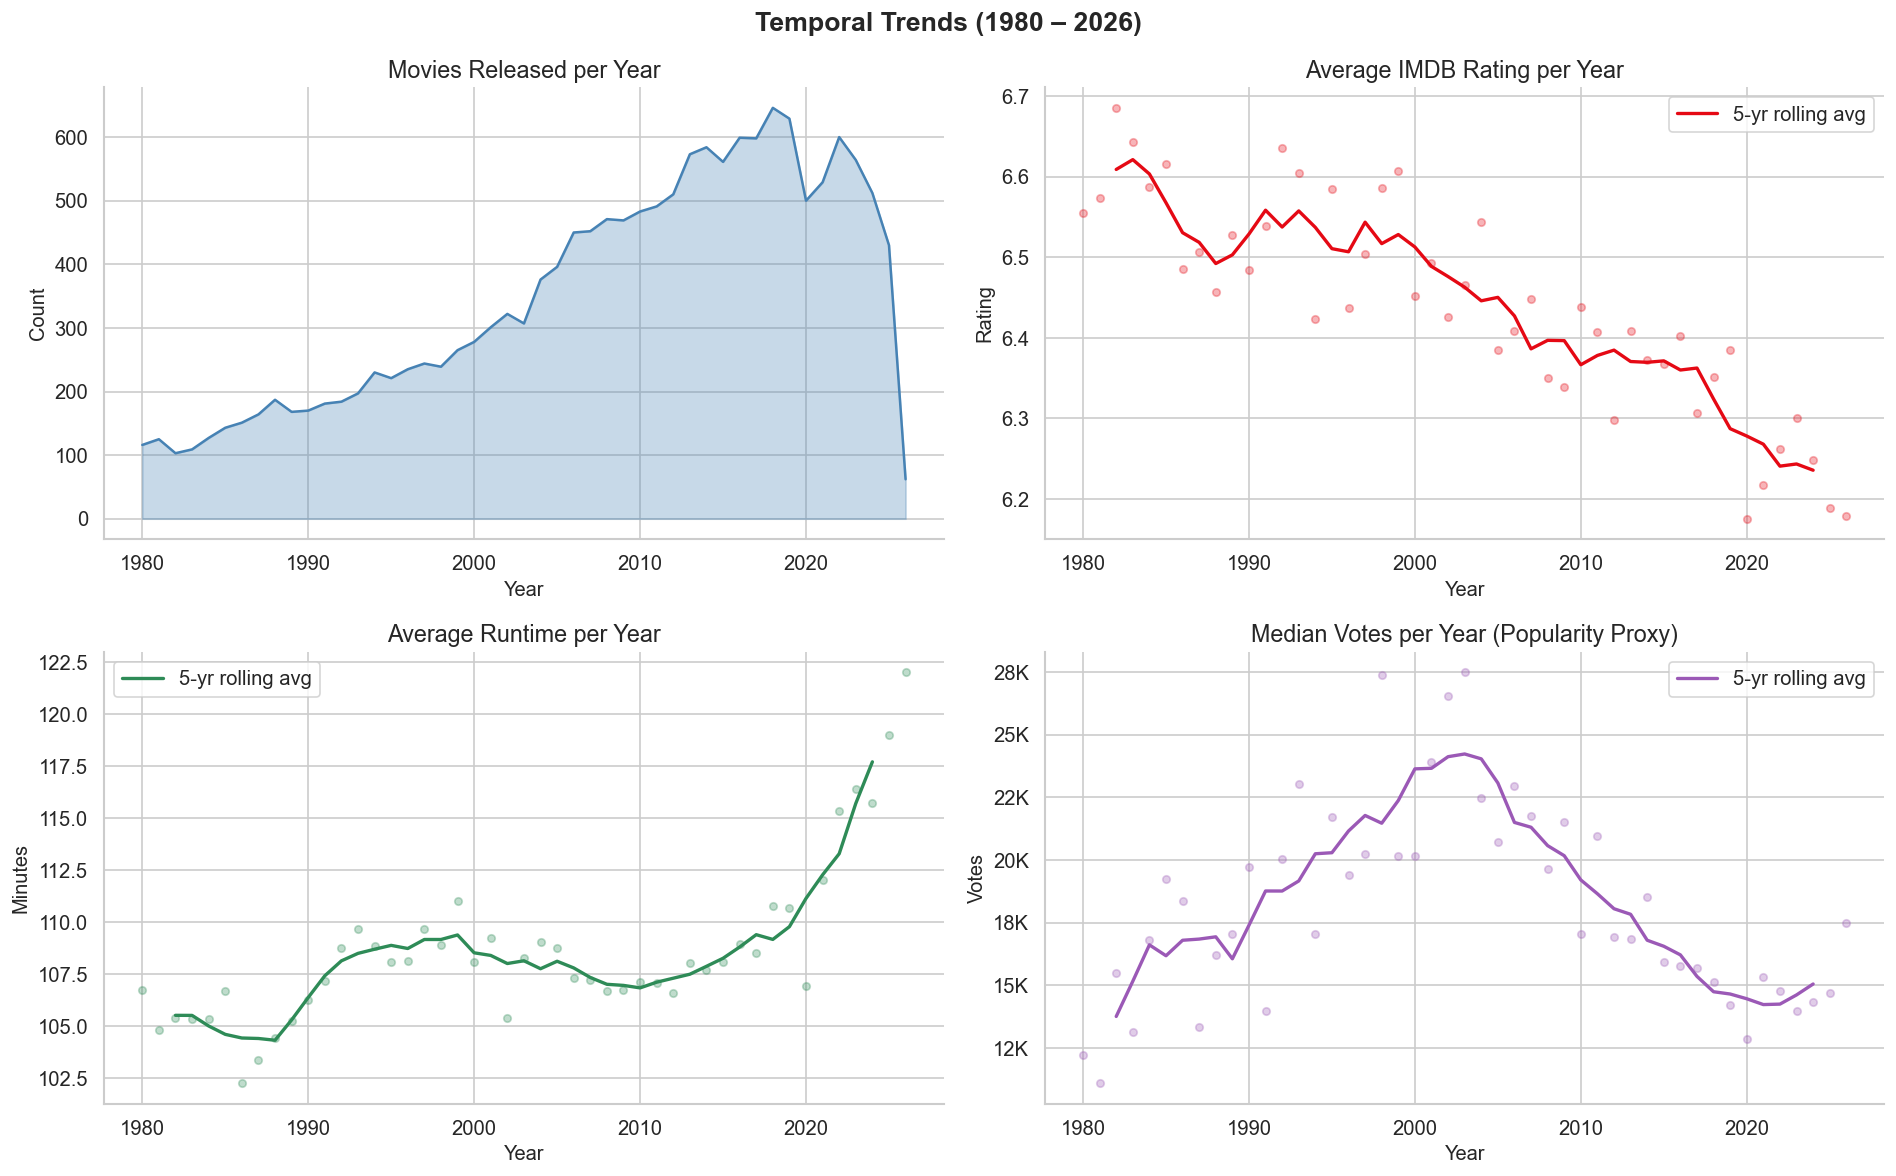

In [10]:
yearly = df.groupby('year').agg(
    movie_count    = ('title',          'count'),
    avg_rating     = ('average_rating', 'mean'),
    avg_runtime    = ('runtime_minutes','mean'),
    median_votes   = ('num_votes',      'median'),
).reset_index()

# Rolling smoothing
for col in ['avg_rating', 'avg_runtime', 'median_votes']:
    yearly[f'{col}_roll5'] = yearly[col].rolling(5, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Movies released per year ──────────────────────────────────────────────
ax = axes[0, 0]
ax.fill_between(yearly['year'], yearly['movie_count'], alpha=0.3, color='steelblue')
ax.plot(yearly['year'], yearly['movie_count'], color='steelblue', lw=1.5)
ax.set_title('Movies Released per Year')
ax.set_ylabel('Count')

# ── Average rating per year ───────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(yearly['year'], yearly['avg_rating'], alpha=0.3, s=20, color=ACCENT)
ax.plot(yearly['year'], yearly['avg_rating_roll5'], color=ACCENT, lw=2, label='5-yr rolling avg')
ax.set_title('Average IMDB Rating per Year')
ax.set_ylabel('Rating')
ax.legend()

# ── Average runtime per year ──────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(yearly['year'], yearly['avg_runtime'], alpha=0.3, s=20, color='seagreen')
ax.plot(yearly['year'], yearly['avg_runtime_roll5'], color='seagreen', lw=2, label='5-yr rolling avg')
ax.set_title('Average Runtime per Year')
ax.set_ylabel('Minutes')
ax.legend()

# ── Median votes per year ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.scatter(yearly['year'], yearly['median_votes'], alpha=0.3, s=20, color='#9b59b6')
ax.plot(yearly['year'], yearly['median_votes_roll5'], color='#9b59b6', lw=2, label='5-yr rolling avg')
ax.set_title('Median Votes per Year (Popularity Proxy)')
ax.set_ylabel('Votes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend()

for ax in axes.flat:
    ax.set_xlabel('Year')

plt.suptitle('Temporal Trends (1980 – 2026)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

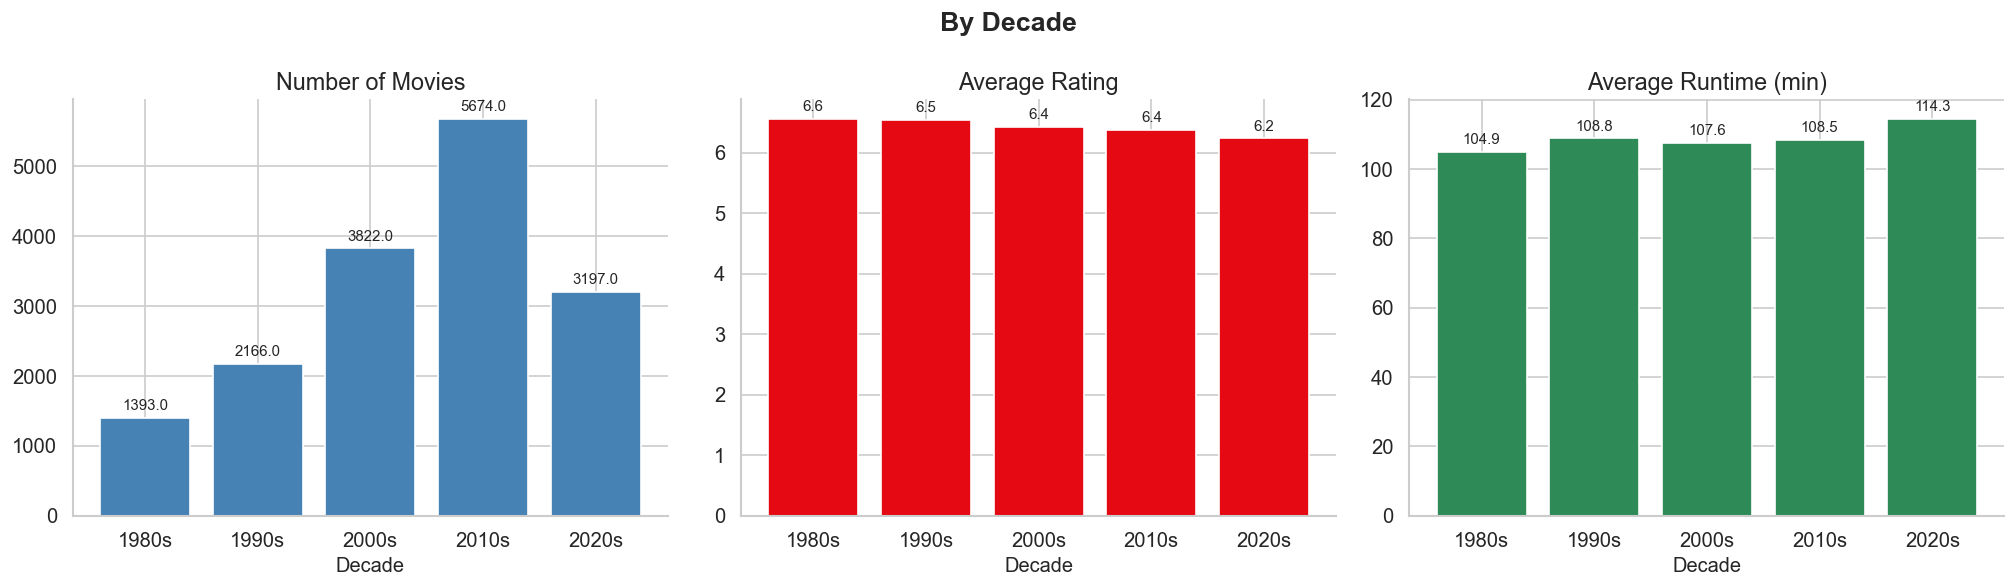

In [11]:
# ── Movies per decade ─────────────────────────────────────────────────────
decade_agg = df.groupby('decade_label').agg(
    count       = ('title',          'count'),
    avg_rating  = ('average_rating', 'mean'),
    avg_runtime = ('runtime_minutes','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, label, color in zip(
    axes,
    ['count', 'avg_rating', 'avg_runtime'],
    ['Number of Movies', 'Average Rating', 'Average Runtime (min)'],
    ['steelblue', ACCENT, 'seagreen']
):
    bars = ax.bar(decade_agg['decade_label'], decade_agg[col], color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Decade')

plt.suptitle('By Decade', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Genre Analysis <a id='6'></a>

In [12]:
# ── Explode genres for per-genre analysis ─────────────────────────────────
gdf = df.copy()
gdf['genres'] = gdf['genres'].fillna('Unknown')
gdf = gdf.assign(genre=gdf['genres'].str.split(',')).explode('genre')
gdf['genre'] = gdf['genre'].str.strip()

genre_stats = gdf.groupby('genre').agg(
    count      = ('title',          'count'),
    avg_rating = ('average_rating', 'mean'),
    med_votes  = ('num_votes',      'median'),
).reset_index().sort_values('count', ascending=False)

# Filter genres with at least 50 appearances
genre_stats = genre_stats[genre_stats['count'] >= 50]

print(f'Unique genres (≥50 films): {len(genre_stats)}')
genre_stats.head(10)

Unique genres (≥50 films): 21


,genre,count,avg_rating,med_votes
7,Drama,9219,6.63,16216.00
4,Comedy,5874,6.27,17383.00
0,Action,3941,6.19,22763.00
5,Crime,3256,6.47,18970.00
19,Thriller,2776,6.13,17406.00
16,Romance,2652,6.44,16236.50
1,Adventure,2337,6.28,39256.00
11,Horror,2193,5.70,16573.00
14,Mystery,1754,6.16,21152.50
3,Biography,1130,7.00,20963.00


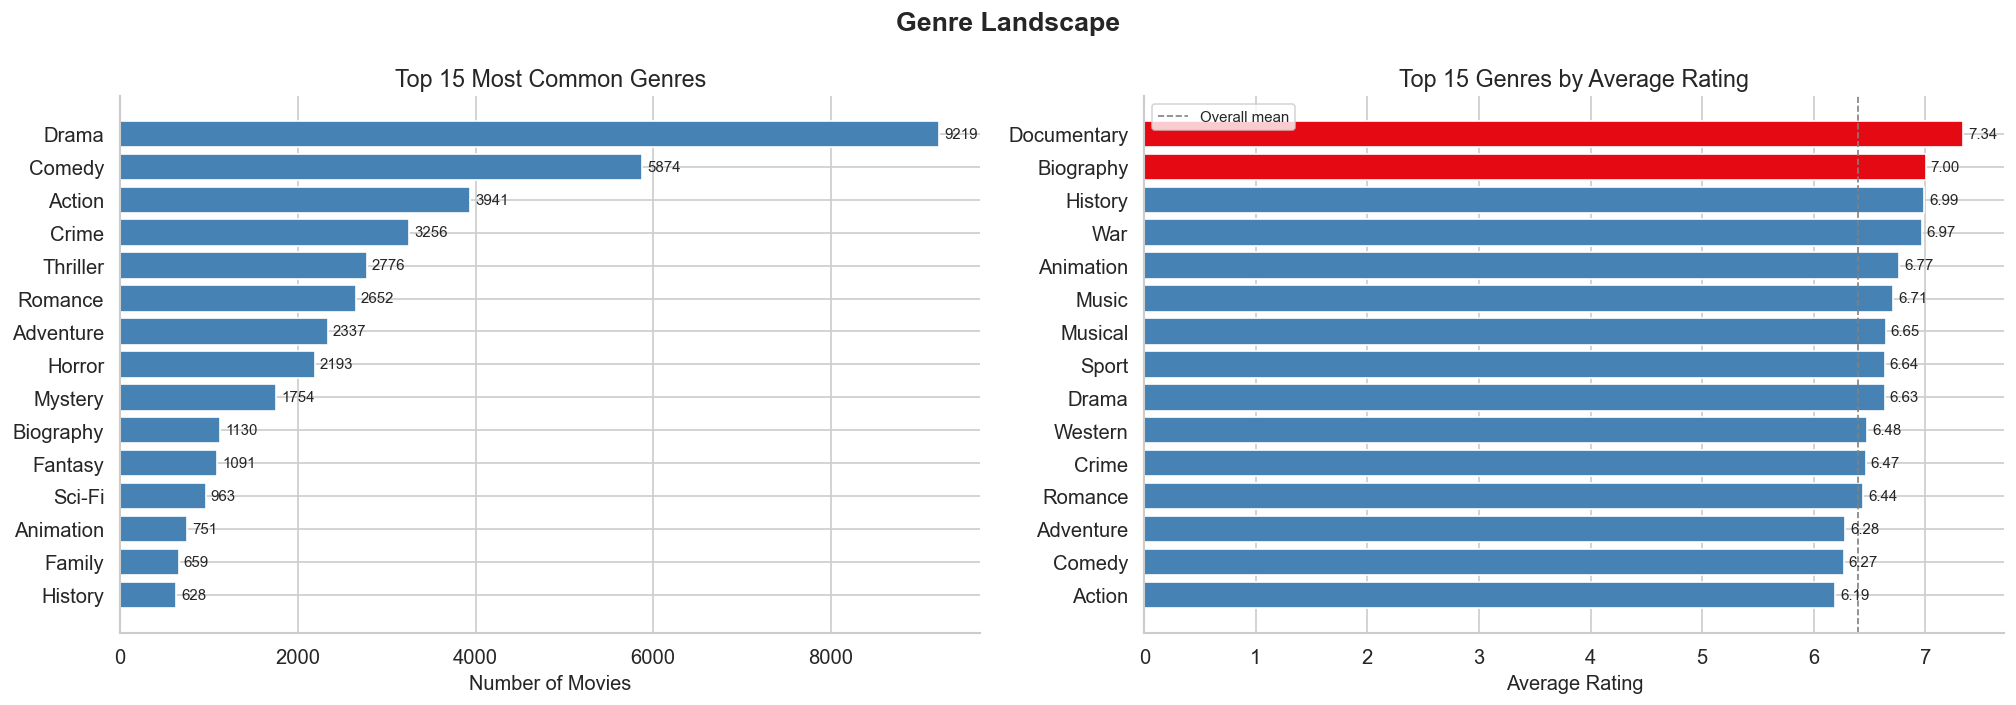

In [13]:
top_genres = genre_stats.nlargest(15, 'count')

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Frequency ─────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(top_genres['genre'][::-1], top_genres['count'][::-1], color='steelblue')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Top 15 Most Common Genres')
ax.set_xlabel('Number of Movies')

# ── Average rating ────────────────────────────────────────────────────────
ax = axes[1]
top_by_rating = genre_stats.nlargest(15, 'avg_rating').sort_values('avg_rating')
colors = [ACCENT if r > 7.0 else 'steelblue' for r in top_by_rating['avg_rating']]
bars = ax.barh(top_by_rating['genre'], top_by_rating['avg_rating'], color=colors)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Top 15 Genres by Average Rating')
ax.set_xlabel('Average Rating')
ax.axvline(df['average_rating'].mean(), color='gray', ls='--', lw=1, label='Overall mean')
ax.legend(fontsize=9)

plt.suptitle('Genre Landscape', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

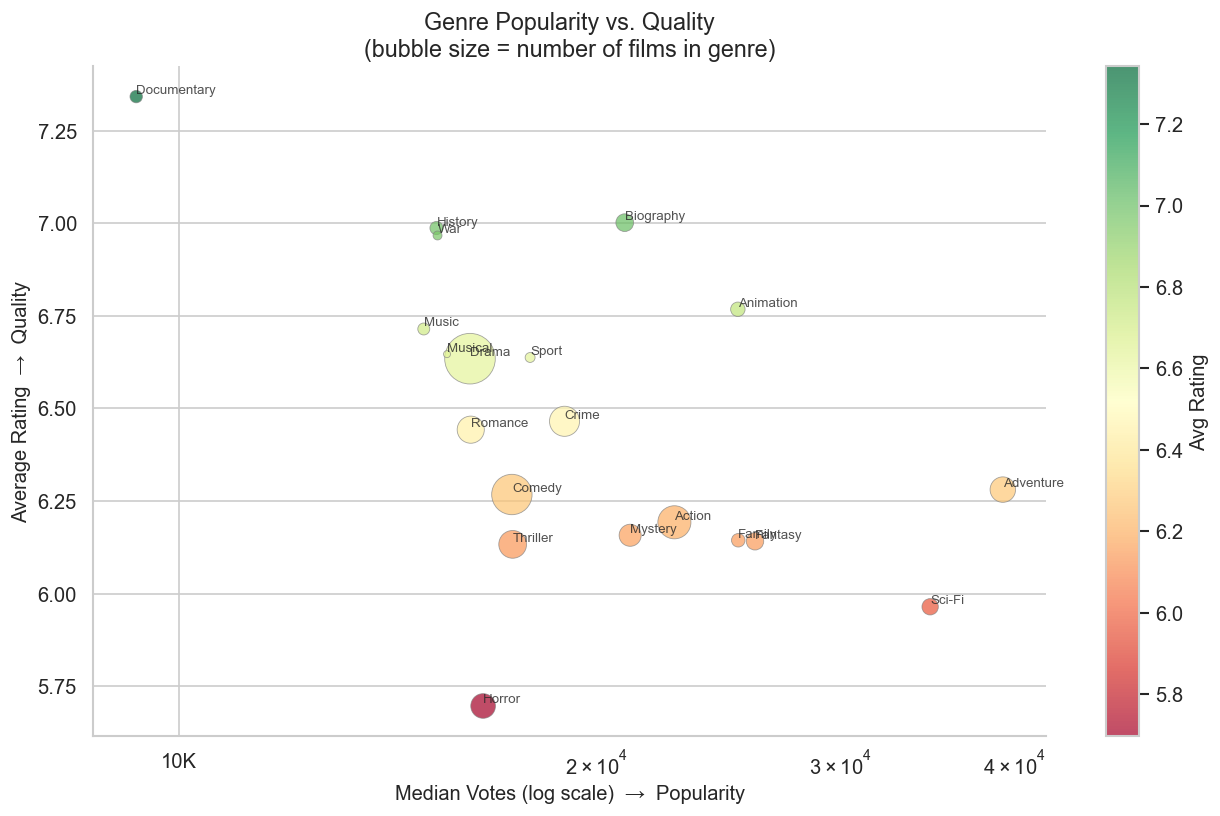

In [14]:
# ── Genre popularity vs. quality scatter ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

plot_gs = genre_stats[genre_stats['count'] >= 100].copy()
scatter = ax.scatter(
    plot_gs['med_votes'],
    plot_gs['avg_rating'],
    s=plot_gs['count'] / 10,
    alpha=0.7,
    c=plot_gs['avg_rating'],
    cmap='RdYlGn',
    edgecolors='gray',
    linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Avg Rating')

for _, row in plot_gs.iterrows():
    ax.annotate(row['genre'], (row['med_votes'], row['avg_rating']),
                fontsize=8, ha='left', va='bottom', alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Median Votes (log scale)  →  Popularity')
ax.set_ylabel('Average Rating  →  Quality')
ax.set_title('Genre Popularity vs. Quality\n(bubble size = number of films in genre)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

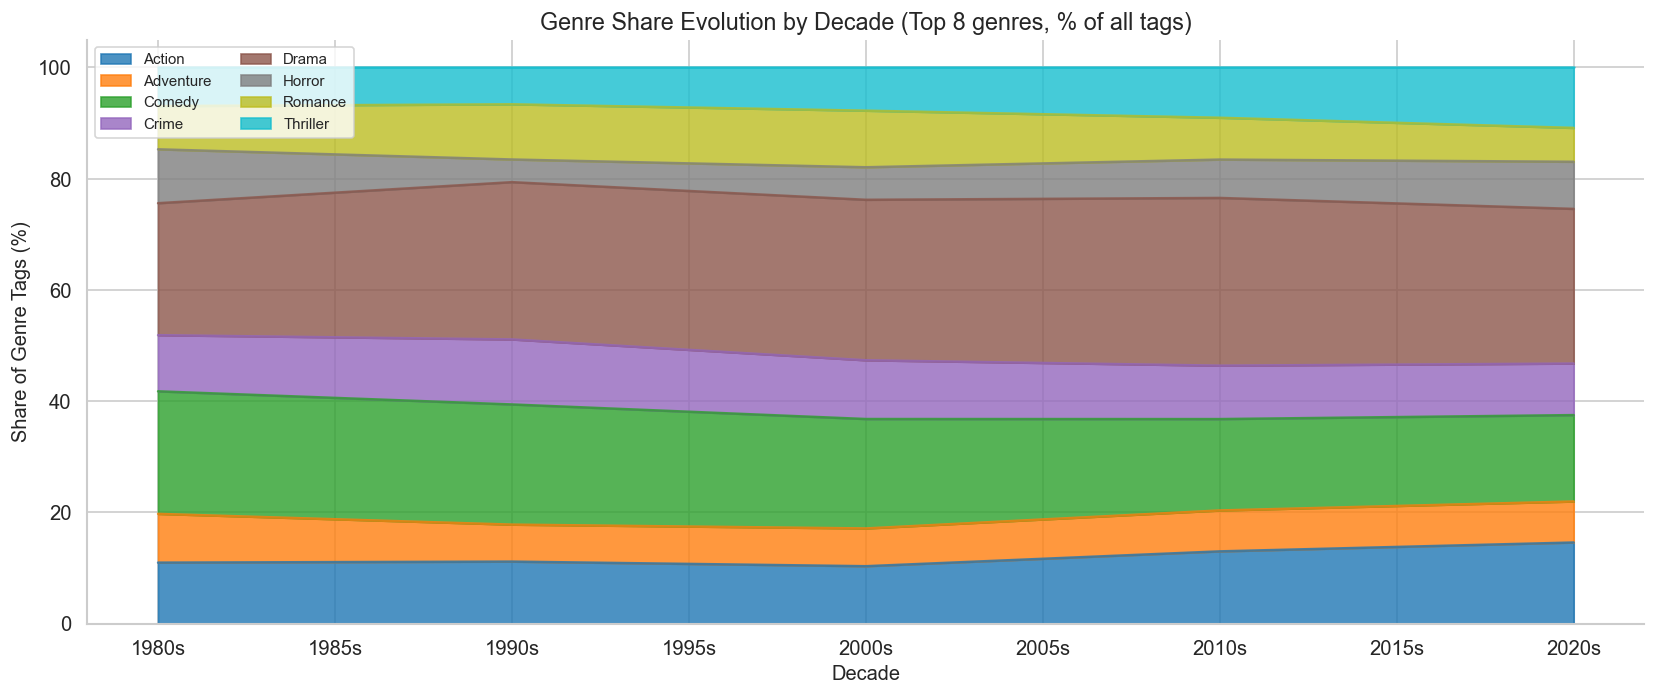

In [15]:
# ── Genre evolution over decades ──────────────────────────────────────────
TOP_N = 8
top_genre_names = genre_stats.nlargest(TOP_N, 'count')['genre'].tolist()

genre_decade = (
    gdf[gdf['genre'].isin(top_genre_names)]
    .groupby(['decade', 'genre'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to % of total films that decade
genre_decade_pct = genre_decade.div(genre_decade.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
genre_decade_pct.plot.area(ax=ax, colormap='tab10', alpha=0.8)
ax.set_title('Genre Share Evolution by Decade (Top 8 genres, % of all tags)', fontsize=14)
ax.set_xlabel('Decade')
ax.set_ylabel('Share of Genre Tags (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}s"))
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

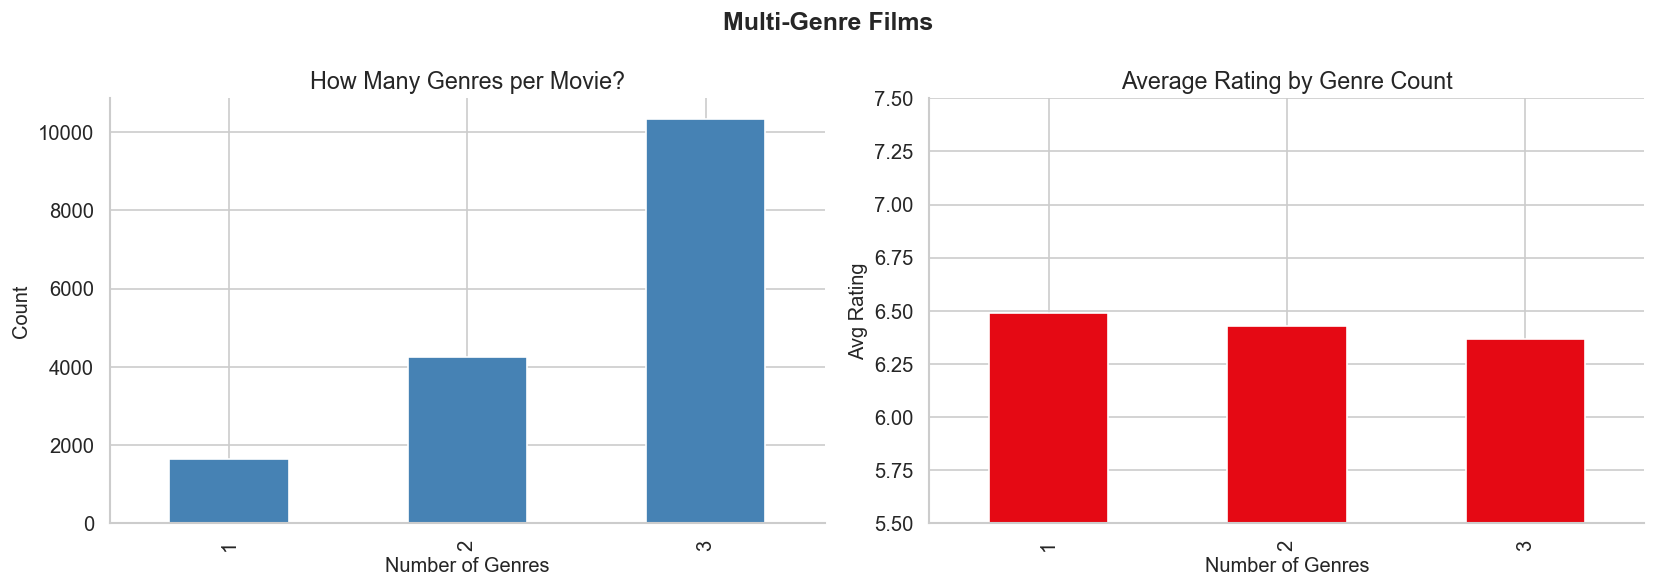

In [16]:
# ── Number of genres per movie ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
df['num_genres'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('How Many Genres per Movie?')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Count')

ax = axes[1]
df.groupby('num_genres')['average_rating'].mean().plot.bar(ax=ax, color=ACCENT, edgecolor='white')
ax.set_title('Average Rating by Genre Count')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Avg Rating')
ax.set_ylim(5.5, 7.5)

plt.suptitle('Multi-Genre Films', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Rating Deep-Dive <a id='7'></a>

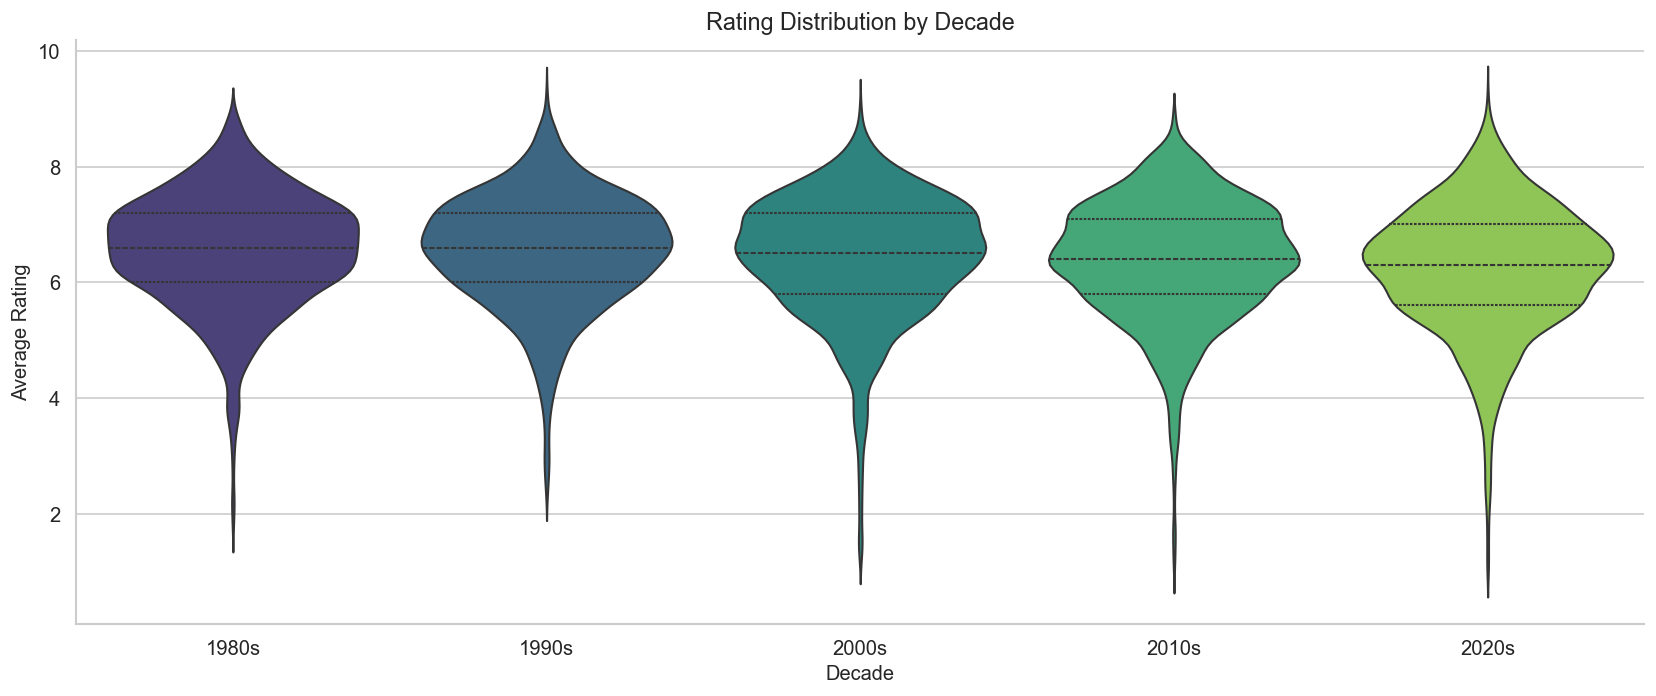

In [17]:
# ── Rating distribution by decade ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

order = sorted(df['decade_label'].unique())
palette = sns.color_palette('viridis', len(order))
sns.violinplot(
    data=df, x='decade_label', y='average_rating',
    order=order, palette=palette, inner='quartile', ax=ax
)
ax.set_title('Rating Distribution by Decade', fontsize=14)
ax.set_xlabel('Decade')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plt.show()

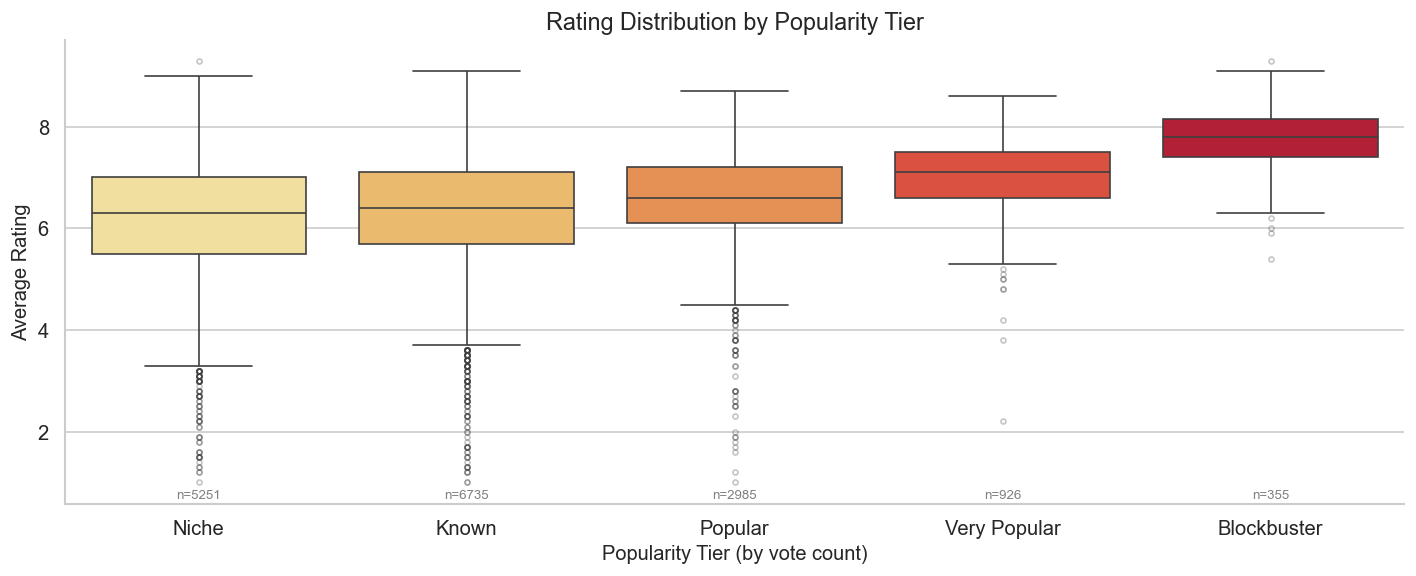

In [18]:
# ── Rating by popularity tier ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
tier_order = ['Niche', 'Known', 'Popular', 'Very Popular', 'Blockbuster']
tier_palette = sns.color_palette('YlOrRd', len(tier_order))
sns.boxplot(
    data=df, x='pop_tier', y='average_rating',
    order=tier_order, palette=tier_palette, ax=ax,
    flierprops={'marker':'o','markersize':3,'alpha':0.3}
)
ax.set_title('Rating Distribution by Popularity Tier')
ax.set_xlabel('Popularity Tier (by vote count)')
ax.set_ylabel('Average Rating')
# Add counts
for i, tier in enumerate(tier_order):
    n = (df['pop_tier'] == tier).sum()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={n}', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

In [19]:
# ── Top 20 highest-rated films (min 50,000 votes) ─────────────────────────
top_rated = (
    df[df['num_votes'] >= 50_000]
    .nlargest(20, 'average_rating')
    [['title','year','genres','average_rating','num_votes']]
    .reset_index(drop=True)
)
top_rated.index += 1
top_rated['num_votes'] = top_rated['num_votes'].apply(lambda x: f'{x:,}')
top_rated.style.background_gradient(cmap='RdYlGn', subset=['average_rating'])

,title,year,genres,average_rating,num_votes
1,The Shawshank Redemption,1994,Drama,9.300000,"3,182,733"
2,The Dark Knight,2008,"Action,Crime,Drama",9.100000,"3,161,984"
3,The Lord of the Rings: The Return of the King,2003,"Adventure,Drama,Fantasy",9.000000,"2,161,551"
4,Schindler's List,1993,"Biography,Drama,History",9.000000,"1,583,450"
5,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure,Drama,Fantasy",8.900000,"2,203,274"
6,Inception,2010,"Action,Adventure,Sci-Fi",8.800000,"2,811,692"
7,Fight Club,1999,"Crime,Drama,Thriller",8.800000,"2,601,984"
8,Forrest Gump,1994,"Drama,Romance",8.800000,"2,492,584"
9,Pulp Fiction,1994,"Crime,Drama",8.800000,"2,431,723"
10,The Lord of the Rings: The Two Towers,2002,"Adventure,Drama,Fantasy",8.800000,"1,954,133"


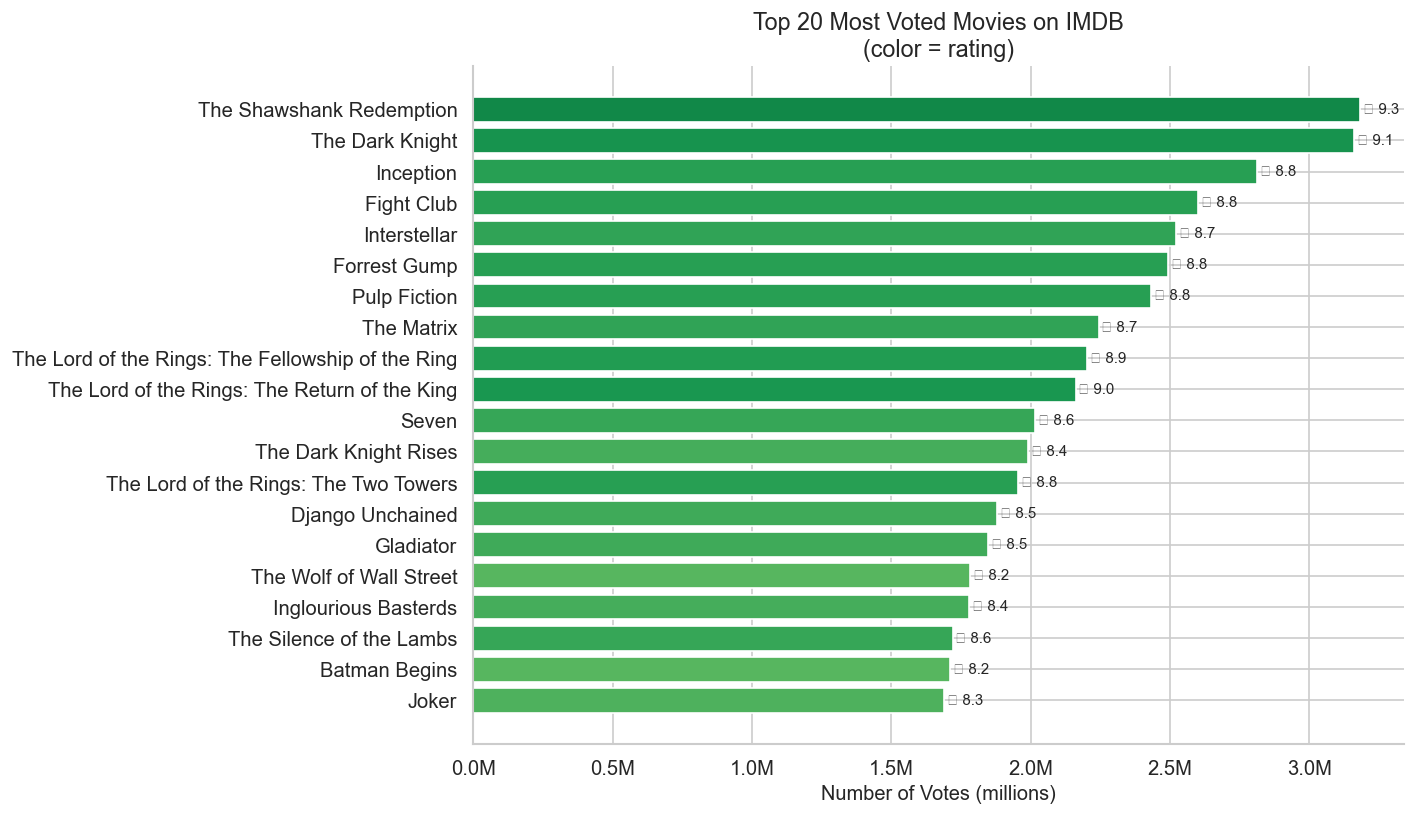

In [20]:
# ── Top 20 most voted (blockbusters) ─────────────────────────────────────
top_voted = (
    df.nlargest(20, 'num_votes')
    [['title','year','genres','average_rating','num_votes']]
    .reset_index(drop=True)
)
top_voted.index += 1

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_voted['title'][::-1], top_voted['num_votes'][::-1] / 1e6,
               color=plt.cm.RdYlGn([r/10 for r in top_voted['average_rating'][::-1]]))
ax.set_title('Top 20 Most Voted Movies on IMDB\n(color = rating)', fontsize=14)
ax.set_xlabel('Number of Votes (millions)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

# Add rating labels
for bar, (_, row) in zip(bars, top_voted.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'⭐ {row["average_rating"]}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Popularity vs. Quality <a id='8'></a>

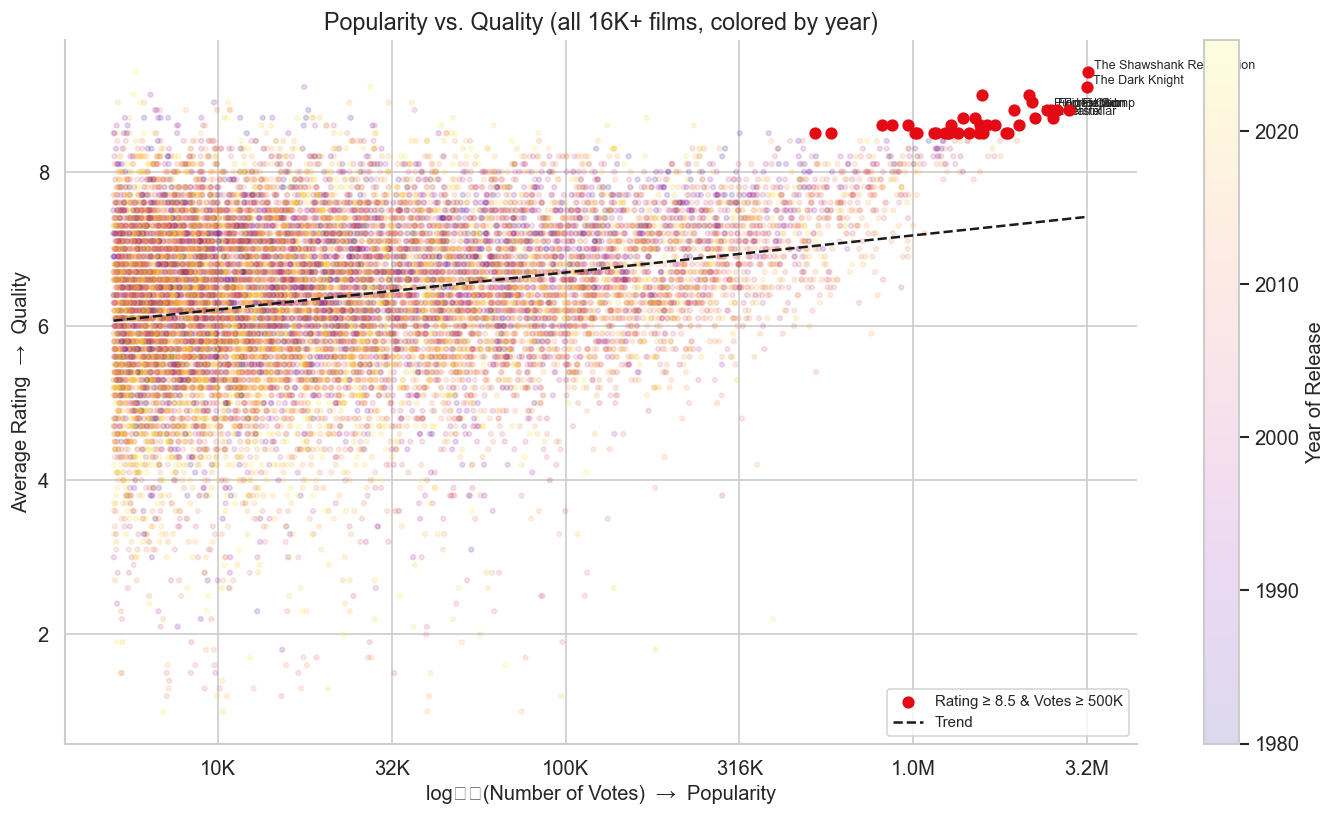

Correlation rating↔votes: 0.252


In [21]:
# ── Rating vs. Votes scatter ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    df['log_votes'],
    df['average_rating'],
    alpha=0.15,
    s=8,
    c=df['year'],
    cmap='plasma',
)
plt.colorbar(sc, ax=ax, label='Year of Release')

# Highlight top-rated + most-voted quadrant
highlight = df[(df['average_rating'] >= 8.5) & (df['num_votes'] >= 500_000)]
ax.scatter(highlight['log_votes'], highlight['average_rating'],
           color=ACCENT, s=40, zorder=5, label='Rating ≥ 8.5 & Votes ≥ 500K')
for _, row in highlight.head(8).iterrows():
    ax.annotate(row['title'], (row['log_votes'], row['average_rating']),
                fontsize=7.5, xytext=(4, 2), textcoords='offset points')

# Trend line
z = np.polyfit(df['log_votes'].dropna(), df.loc[df['log_votes'].notna(), 'average_rating'], 1)
p = np.poly1d(z)
xline = np.linspace(df['log_votes'].min(), df['log_votes'].max(), 100)
ax.plot(xline, p(xline), 'k--', lw=1.5, label='Trend')

ax.set_xlabel('log₁₀(Number of Votes)  →  Popularity')
ax.set_ylabel('Average Rating  →  Quality')
ax.set_title('Popularity vs. Quality (all 16K+ films, colored by year)', fontsize=14)
ax.legend(fontsize=9)

tick_vals = [4, 4.5, 5, 5.5, 6, 6.5]
ax.set_xticks(tick_vals)
ax.set_xticklabels([f'{10**v/1e3:.0f}K' if 10**v < 1e6 else f'{10**v/1e6:.1f}M' for v in tick_vals])

plt.tight_layout()
plt.show()

corr = df[['average_rating','log_votes','runtime_minutes','year']].corr()
print(f'Correlation rating↔votes: {corr.loc["average_rating","log_votes"]:.3f}')

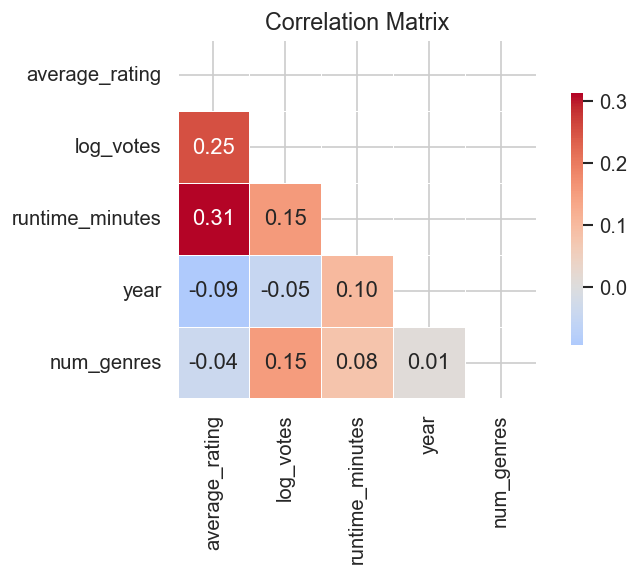

In [22]:
# ── Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_data = df[['average_rating','log_votes','runtime_minutes','year','num_genres']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(
    corr_data, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.7}
)
ax.set_title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

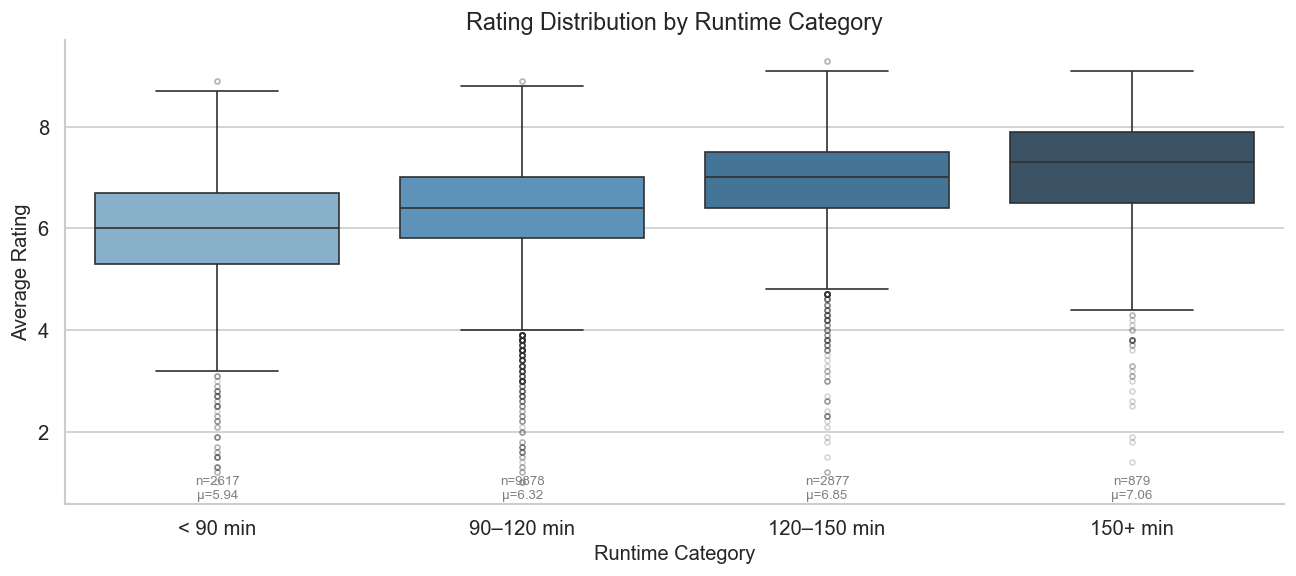

In [23]:
# ── Rating vs. Runtime ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

order_rt = ['< 90 min', '90–120 min', '120–150 min', '150+ min']
sns.boxplot(
    data=df.dropna(subset=['runtime_cat']),
    x='runtime_cat', y='average_rating',
    order=order_rt, palette='Blues_d', ax=ax,
    flierprops={'marker':'o','markersize':3,'alpha':0.2}
)
ax.set_title('Rating Distribution by Runtime Category')
ax.set_xlabel('Runtime Category')
ax.set_ylabel('Average Rating')

for i, cat in enumerate(order_rt):
    n = (df['runtime_cat'] == cat).sum()
    m = df[df['runtime_cat'] == cat]['average_rating'].mean()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={n}\nμ={m:.2f}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## 9. Decade Spotlights <a id='9'></a>

In [24]:
# ── Best-rated film of each decade (≥50K votes) ───────────────────────────
best_per_decade = (
    df[df['num_votes'] >= 50_000]
    .sort_values('average_rating', ascending=False)
    .groupby('decade_label')
    .first()
    .reset_index()
    [['decade_label','title','year','genres','average_rating','num_votes']]
)
print('Best-rated film per decade (min 50K votes):')
best_per_decade.style.background_gradient(cmap='Greens', subset=['average_rating'])

Best-rated film per decade (min 50K votes):


,decade_label,title,year,genres,average_rating,num_votes
0,1980s,Star Wars: Episode V - The Empire Strikes Back,1980,"Action,Adventure,Fantasy",8.700000,1502466
1,1990s,The Shawshank Redemption,1994,Drama,9.300000,3182733
2,2000s,The Dark Knight,2008,"Action,Crime,Drama",9.100000,3161984
3,2010s,Inception,2010,"Action,Adventure,Sci-Fi",8.800000,2811692
4,2020s,12th Fail,2023,"Biography,Drama",8.700000,170858


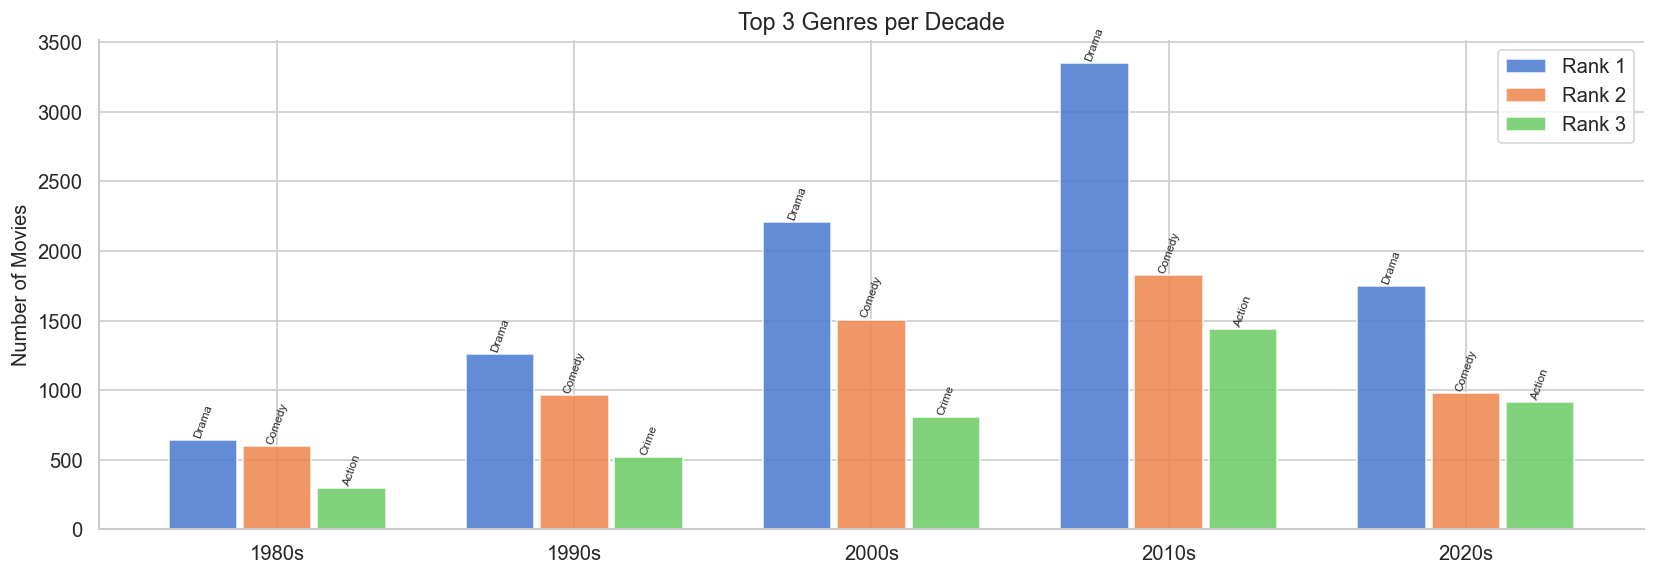

In [25]:
# ── Top genre per decade ──────────────────────────────────────────────────
top_genre_decade = (
    gdf.groupby(['decade_label', 'genre'])
    .size()
    .reset_index(name='count')
    .sort_values(['decade_label','count'], ascending=[True, False])
    .groupby('decade_label')
    .head(3)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 5))
decades = sorted(df['decade_label'].unique())
x = np.arange(len(decades))
width = 0.25

# Plot top-3 genres per decade as grouped bars
for rank, (offset, label) in enumerate(zip([-width, 0, width], ['#1', '#2', '#3']), 1):
    subset = (
        top_genre_decade
        .groupby('decade_label')
        .nth(rank - 1)
        .reset_index()
    )
    bars = ax.bar(
        x + offset, subset['count'], width=width-0.02,
        label=f'Rank {rank}', alpha=0.85
    )
    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                row['genre'], ha='center', va='bottom', fontsize=7, rotation=70)

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_title('Top 3 Genres per Decade', fontsize=14)
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Key Findings <a id='10'></a>

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Drama dominates** — it's the most common genre across every decade, often paired with other genres | Genre frequency analysis |
| 2 | **More votes → higher ratings** — popular films are rated better (positive correlation ~0.30) | Correlation matrix & scatter plot |
| 3 | **Longer films rated higher** — 150+ min films average ~6.8 vs. ~6.1 for films under 90 min | Rating by runtime category |
| 4 | **Film output has exploded** — annual releases increased ~5× from 1980 to 2020s | Movies per year trend |
| 5 | **Average ratings have declined slightly** over decades, likely due to more low-budget/niche content entering the dataset | Rolling avg rating by year |
| 6 | **Action/Sci-Fi surge** — these genres grew sharply post-2000, driven by franchise filmmaking | Genre evolution area chart |
| 7 | **The 1990s had the highest average ratings** among all decades | Decade violin plot |
| 8 | **Niche films (< 10K votes) have wider rating spread** — some are hidden gems, many are poor | Rating by popularity tier |
| 9 | **Multi-genre films score slightly lower** on average — genre blending may dilute audience expectations | Rating by genre count |
| 10 | **The Shawshank Redemption (1994) remains #1** with the highest rating AND most votes | Top rated table |

In [26]:
# ── Summary statistics table ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total movies', 'Year range', 'Unique genres',
        'Avg rating (overall)', 'Highest-rated film',
        'Most-voted film', 'Avg runtime (min)',
        'Avg votes per film', 'Missing data'
    ],
    'Value': [
        f'{len(df):,}',
        f"{df['year'].min()} – {df['year'].max()}",
        str(gdf['genre'].nunique()),
        f"{df['average_rating'].mean():.2f}",
        df.nlargest(1,'average_rating')[['title','average_rating']].to_string(index=False),
        df.nlargest(1,'num_votes')[['title','num_votes']].to_string(index=False),
        f"{df['runtime_minutes'].mean():.0f} min",
        f"{df['num_votes'].mean():,.0f}",
        'runtime: 1 row, genres: 6 rows (<0.1%)'
    ]
})
summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,Value
Total movies,"16,252"
Year range,1980 – 2026
Unique genres,23
Avg rating (overall),6.40
Highest-rated film,title average_rating The Shawshank Redemption 9.30
Most-voted film,title num_votes The Shawshank Redemption 3182733
Avg runtime (min),109 min
Avg votes per film,"66,332"
Missing data,"runtime: 1 row, genres: 6 rows (<0.1%)"
